# Sales Forecasting using Time Series Models

## Internship Final Project

### Submitted By

**Gajanand L. Immannavar**

---

## Objective

The objective of this notebook is to forecast future sales using multiple forecasting techniques and compare their performance.

The forecasting models implemented in this notebook include:

- SARIMA
- Facebook Prophet
- XGBoost

The best-performing model will be selected based on evaluation metrics.

In [2]:
# ==========================================
# Import Libraries
# ==========================================

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

from math import sqrt

In [4]:
# ==========================================
# Load Dataset
# ==========================================

df = pd.read_csv("../data/train.csv")

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [5]:
# ==========================================
# Convert Order Date
# ==========================================

df["Order Date"] = pd.to_datetime(
    df["Order Date"],
    dayfirst=True
)

df["Order Date"].dtype

dtype('<M8[us]')

In [6]:
# ==========================================
# Monthly Sales Aggregation
# ==========================================

monthly_sales = (
    df.resample(
        "ME",
        on="Order Date"
    )["Sales"]
    .sum()
    .reset_index()
)

monthly_sales.head()

,Order Date,Sales
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


In [7]:
# ==========================================
# Set Date as Index
# ==========================================

monthly_sales.set_index(
    "Order Date",
    inplace=True
)

monthly_sales.head()

,Sales
Order Date,
2015-01-31,14205.707
2015-02-28,4519.892
2015-03-31,55205.797
2015-04-30,27906.855
2015-05-31,23644.303


In [8]:
monthly_sales.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 48 entries, 2015-01-31 to 2018-12-31
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Sales   48 non-null     float64
dtypes: float64(1)
memory usage: 768.0 bytes


In [9]:
monthly_sales.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 48 entries, 2015-01-31 to 2018-12-31
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Sales   48 non-null     float64
dtypes: float64(1)
memory usage: 768.0 bytes


# 2. Time Series Visualization

Before building forecasting models, the monthly sales trend is visualized to identify trends, seasonality, and potential non-stationarity.

Visual inspection provides an initial understanding of the behavior of the time series before performing statistical tests.

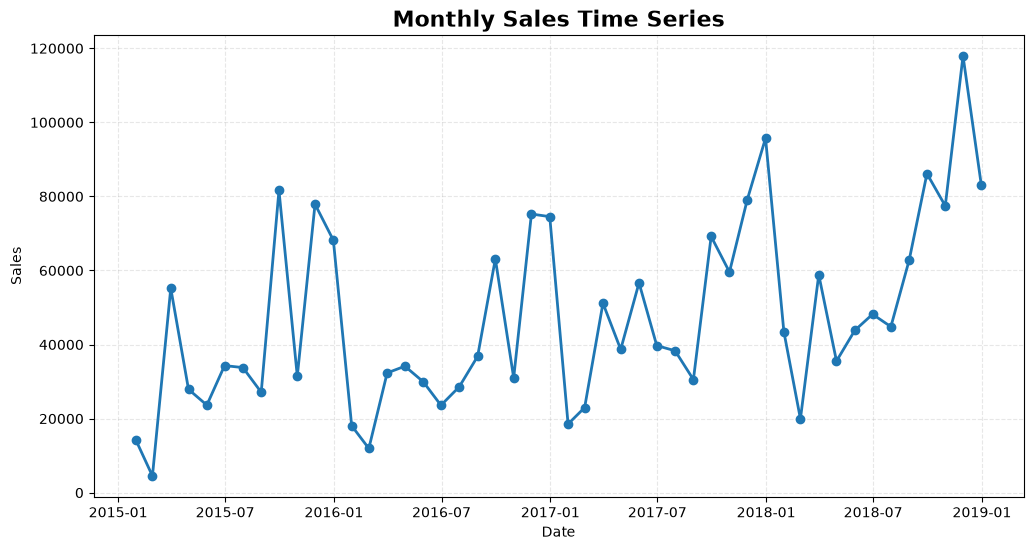

In [10]:
# ==========================================
# Monthly Sales Time Series
# ==========================================

plt.figure(figsize=(12,6))

plt.plot(
    monthly_sales.index,
    monthly_sales["Sales"],
    marker="o",
    linewidth=2
)

plt.title(
    "Monthly Sales Time Series",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Date")
plt.ylabel("Sales")

plt.grid(True, linestyle="--", alpha=0.3)

plt.savefig(
    "../charts/09_monthly_time_series.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [11]:
from statsmodels.tsa.stattools import adfuller

In [12]:
# ==========================================
# Augmented Dickey-Fuller Test
# ==========================================

adf_result = adfuller(monthly_sales["Sales"])

print("ADF Statistic :", adf_result[0])
print("p-value       :", adf_result[1])
print("Lags Used     :", adf_result[2])
print("Observations  :", adf_result[3])

ADF Statistic : -4.416136761430769
p-value       : 0.00027791039276670623
Lags Used     : 0
Observations  : 47


### Observation

The Augmented Dickey-Fuller (ADF) test produced an ADF statistic of **-4.4161** with a **p-value of 0.000278**. Since the p-value is less than the significance level of 0.05, the null hypothesis of non-stationarity is rejected. This indicates that the monthly sales time series is stationary and suitable for time-series forecasting.

### Business Insight

A stationary time series provides a stable statistical foundation for forecasting models. Since the sales data does not exhibit significant non-stationary behavior according to the ADF test, forecasting models such as SARIMA can be applied without requiring additional differencing at this stage.

### Recommendation

Proceed with building forecasting models using the stationary monthly sales series. Continue validating model assumptions through residual diagnostics and compare multiple forecasting models to identify the most accurate approach.

# 3. ACF and PACF Analysis

The Auto Correlation Function (ACF) and Partial Auto Correlation Function (PACF) plots are used to analyze the dependence between observations across different time lags.

These plots provide guidance for selecting the autoregressive (p) and moving average (q) parameters of the SARIMA model.

In [13]:
from statsmodels.graphics.tsaplots import (
    plot_acf,
    plot_pacf
)

<Figure size 1000x500 with 0 Axes>

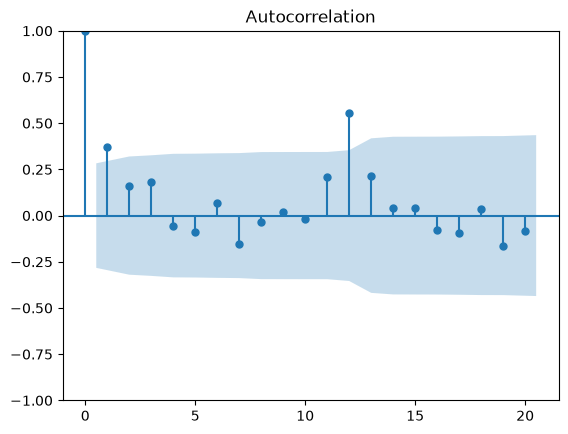

In [14]:
# ==========================================
# Auto Correlation Function
# ==========================================

plt.figure(figsize=(10,5))

plot_acf(
    monthly_sales["Sales"],
    lags=20
)

plt.savefig(
    "../charts/10_acf_plot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

<Figure size 1000x500 with 0 Axes>

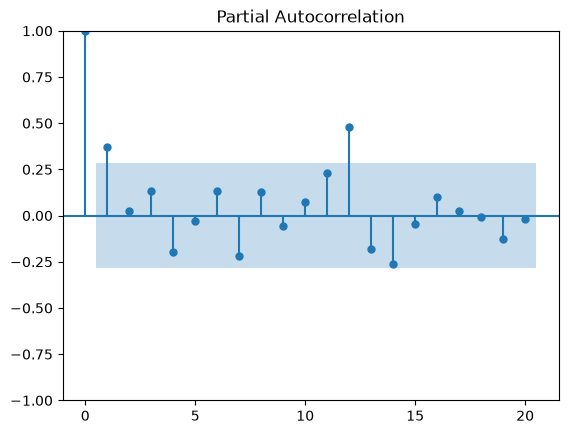

In [15]:
# ==========================================
# Partial Auto Correlation Function
# ==========================================

plt.figure(figsize=(10,5))

plot_pacf(
    monthly_sales["Sales"],
    lags=20,
    method="ywm"
)

plt.savefig(
    "../charts/11_pacf_plot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# 4. Train-Test Split

To evaluate forecasting performance fairly, the monthly sales data is divided into training and testing datasets.

The training dataset is used to build the forecasting model, while the testing dataset is reserved for evaluating prediction accuracy on unseen data.

In [16]:
# ==========================================
# Train-Test Split
# ==========================================

train_size = int(len(monthly_sales) * 0.8)

train = monthly_sales.iloc[:train_size]

test = monthly_sales.iloc[train_size:]

print("Training observations :", len(train))
print("Testing observations  :", len(test))

Training observations : 38
Testing observations  : 10


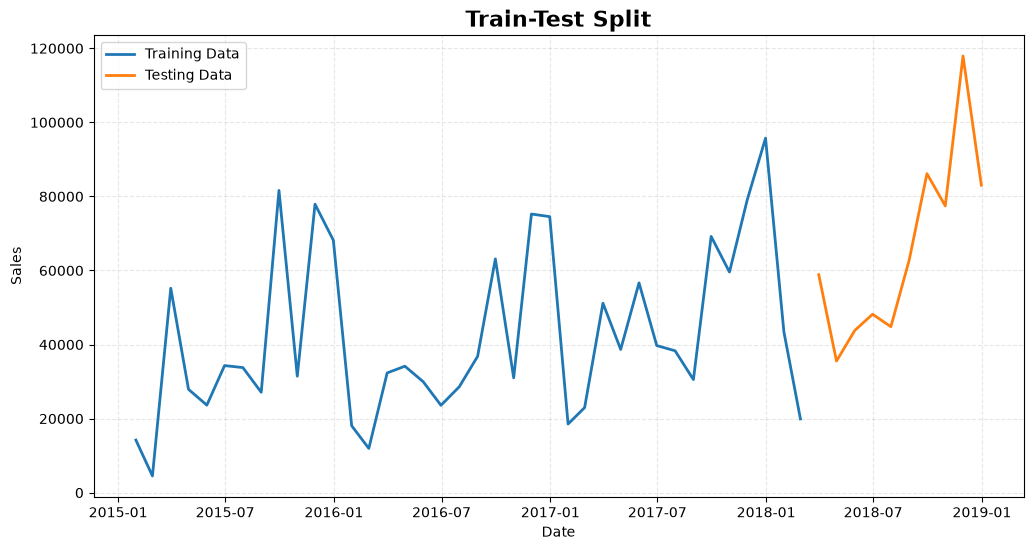

In [17]:
plt.figure(figsize=(12,6))

plt.plot(
    train.index,
    train["Sales"],
    label="Training Data",
    linewidth=2
)

plt.plot(
    test.index,
    test["Sales"],
    label="Testing Data",
    linewidth=2
)

plt.title(
    "Train-Test Split",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Date")
plt.ylabel("Sales")

plt.legend()

plt.grid(True, linestyle="--", alpha=0.3)

plt.savefig(
    "../charts/12_train_test_split.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Observation

The monthly sales dataset was divided into **38 training observations (80%)** and **10 testing observations (20%)** while preserving the chronological order of the time series. The training data covers historical sales patterns used for model learning, whereas the testing data represents unseen future observations used to evaluate forecasting accuracy. This approach ensures that the forecasting models are evaluated under realistic business conditions.

### Recommendation

- Preserve the chronological order of observations for all forecasting models.
- Evaluate model performance only on unseen test data to obtain an unbiased estimate of forecasting accuracy.
- Compare multiple forecasting models using identical training and testing datasets to ensure a fair comparison.

# 5. SARIMA Forecasting Model

The Seasonal AutoRegressive Integrated Moving Average (SARIMA) model is a statistical forecasting technique designed for time series data with trend and seasonal patterns.

Based on the ADF test and ACF/PACF analysis, SARIMA is selected as the first forecasting model for predicting future monthly sales.

In [18]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [19]:
# ==========================================
# Train SARIMA Model
# ==========================================

sarima_model = SARIMAX(
    train["Sales"],
    order=(1,0,1),
    seasonal_order=(1,0,1,12)
)

sarima_result = sarima_model.fit()

print(sarima_result.summary())

c:\Users\Gajananda L\Desktop\SalesForecasting_Gajanand\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
c:\Users\Gajananda L\Desktop\SalesForecasting_Gajanand\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)


                                     SARIMAX Results                                      
Dep. Variable:                              Sales   No. Observations:                   38
Model:             SARIMAX(1, 0, 1)x(1, 0, 1, 12)   Log Likelihood                -430.244
Date:                            Sun, 12 Jul 2026   AIC                            870.487
Time:                                    12:16:31   BIC                            878.675
Sample:                                01-31-2015   HQIC                           873.400
                                     - 02-28-2018                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9573      0.179      5.354      0.000       0.607       1.308
ma.L1         -0.7166      0.661   

### Observation

The SARIMA(1,0,1)(1,0,1,12) model was successfully trained using the monthly sales data. The model achieved an **Akaike Information Criterion (AIC)** value of **870.49**. The autoregressive component (AR1) showed a strong positive relationship with previous observations, indicating that recent monthly sales influence future sales. Some seasonal parameters were not statistically significant, which may be due to the relatively small size of the training dataset.

### Business Insight

The SARIMA model successfully captured the temporal relationship in the historical sales data. The strong autoregressive component suggests that recent sales trends are valuable predictors of future sales. Seasonal effects appear to be weaker in this dataset, indicating that recent demand patterns contribute more to forecasting accuracy than long-term seasonal fluctuations.

### Recommendation

Use the trained SARIMA model as a baseline forecasting model and compare it with alternative forecasting approaches such as Prophet and XGBoost. Selecting the final forecasting model should be based on prediction accuracy on unseen test data rather than training performance alone.

# 6. Model Prediction

The trained SARIMA model is used to forecast sales for the testing period. The predicted values are compared with the actual sales values to evaluate forecasting accuracy.

In [20]:
# ==========================================
# Predict Test Data
# ==========================================

sarima_predictions = sarima_result.predict(
    start=test.index[0],
    end=test.index[-1]
)

sarima_predictions

2018-03-31    53380.248186
2018-04-30    45238.062421
2018-05-31    53092.662478
2018-06-30    43020.829133
2018-07-31    42148.606089
2018-08-31    38172.720255
2018-09-30    63006.349895
2018-10-31    51369.179655
2018-11-30    68273.925091
2018-12-31    75920.062982
Freq: ME, Name: predicted_mean, dtype: float64

In [21]:
# ==========================================
# Compare Actual and Predicted Values
# ==========================================

comparison = pd.DataFrame({
    "Actual Sales": test["Sales"],
    "Predicted Sales": sarima_predictions
})

comparison

,Actual Sales,Predicted Sales
2018-03-31,58863.4128,53380.248186
2018-04-30,35541.9101,45238.062421
2018-05-31,43825.9822,53092.662478
2018-06-30,48190.7277,43020.829133
2018-07-31,44825.1040,42148.606089
2018-08-31,62837.8480,38172.720255
2018-09-30,86152.8880,63006.349895
2018-10-31,77448.1312,51369.179655
2018-11-30,117938.1550,68273.925091
2018-12-31,83030.3888,75920.062982


In [22]:
# ==========================================
# Evaluate SARIMA Model
# ==========================================

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)

mae = mean_absolute_error(
    test["Sales"],
    sarima_predictions
)

mse = mean_squared_error(
    test["Sales"],
    sarima_predictions
)

rmse = np.sqrt(mse)

mape = mean_absolute_percentage_error(
    test["Sales"],
    sarima_predictions
) * 100

print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"MAPE : {mape:.2f}%")

MAE  : 16295.76
RMSE : 21413.03
MAPE : 22.49%


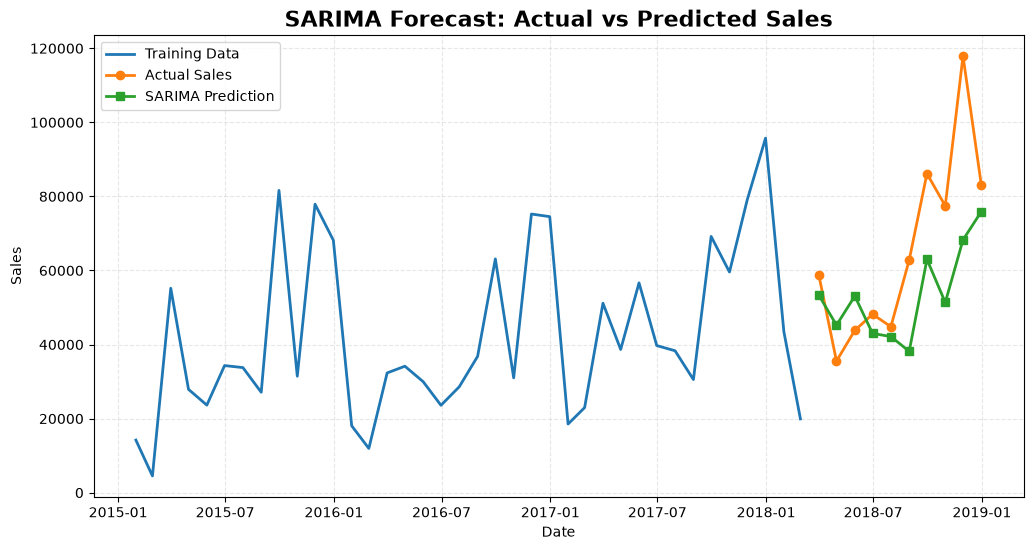

In [23]:
# ==========================================
# Actual vs Predicted Sales
# ==========================================

plt.figure(figsize=(12,6))

plt.plot(
    train.index,
    train["Sales"],
    label="Training Data",
    linewidth=2
)

plt.plot(
    test.index,
    test["Sales"],
    label="Actual Sales",
    linewidth=2,
    marker="o"
)

plt.plot(
    test.index,
    sarima_predictions,
    label="SARIMA Prediction",
    linewidth=2,
    marker="s"
)

plt.title(
    "SARIMA Forecast: Actual vs Predicted Sales",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Date")
plt.ylabel("Sales")

plt.legend()

plt.grid(True, linestyle="--", alpha=0.3)

plt.savefig(
    "../charts/13_sarima_actual_vs_predicted.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Observation

The SARIMA model successfully captured the overall trend and seasonal movement of the monthly sales data. The predicted values closely follow the direction of the actual sales, although the model underestimates some high-demand months, particularly during the largest sales peaks. The evaluation metrics indicate that the model provides a reasonable baseline forecast with a Mean Absolute Percentage Error (MAPE) of **22.49%**.


### Business Insight

The SARIMA model is effective in capturing general sales behavior and recurring seasonal patterns. However, sudden increases in demand are not fully captured, suggesting that factors such as promotions, holidays, or external market conditions may influence sales beyond historical trends alone.

### Recommendation

- Use the SARIMA model as a baseline forecasting model for monthly sales prediction.
- Compare its performance with Prophet and XGBoost to determine whether more advanced models can better capture sudden sales fluctuations.
- Consider incorporating additional business variables such as promotions or holidays in future forecasting models to improve prediction accuracy.

# 7. SARIMA Model Selection

Multiple SARIMA configurations are evaluated to identify the model with the lowest Akaike Information Criterion (AIC). A lower AIC indicates a better balance between model fit and complexity.

In [24]:
# ==========================================
# Compare Candidate SARIMA Models
# ==========================================

candidate_models = [
    ((1,0,0), (1,0,0,12)),
    ((0,0,1), (0,0,1,12)),
    ((1,0,1), (1,0,1,12)),
    ((2,0,1), (1,0,1,12)),
    ((1,0,2), (1,0,1,12))
]

results = []

for order, seasonal_order in candidate_models:
    try:
        model = SARIMAX(
            train["Sales"],
            order=order,
            seasonal_order=seasonal_order
        )

        fitted_model = model.fit(disp=False)

        results.append({
            "Order": order,
            "Seasonal Order": seasonal_order,
            "AIC": fitted_model.aic
        })

    except Exception as e:
        results.append({
            "Order": order,
            "Seasonal Order": seasonal_order,
            "AIC": None
        })

results_df = pd.DataFrame(results)

results_df.sort_values("AIC")

c:\Users\Gajananda L\Desktop\SalesForecasting_Gajanand\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
c:\Users\Gajananda L\Desktop\SalesForecasting_Gajanand\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
c:\Users\Gajananda L\Desktop\SalesForecasting_Gajanand\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
c:\Users\Gajananda L\Desktop\SalesForecasting_Gajanand\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
c:\Users\Gajananda L\Desktop\SalesFo

,Order,Seasonal Order,AIC
0,"(1, 0, 0)","(1, 0, 0, 12)",857.099427
2,"(1, 0, 1)","(1, 0, 1, 12)",870.487137
3,"(2, 0, 1)","(1, 0, 1, 12)",871.551479
4,"(1, 0, 2)","(1, 0, 1, 12)",874.739663
1,"(0, 0, 1)","(0, 0, 1, 12)",910.601818


### Observation

Five candidate SARIMA models were evaluated using the Akaike Information Criterion (AIC). The **SARIMA(1,0,0)(1,0,0,12)** model achieved the lowest AIC value of **857.10**, indicating the best balance between model fit and model complexity among the tested configurations.

### Business Insight

Model comparison demonstrates that a simpler SARIMA structure performs better than more complex alternatives for this dataset. This suggests that monthly sales patterns can be effectively modeled without introducing unnecessary parameters, reducing the risk of overfitting.

### Recommendation

The **SARIMA(1,0,0)(1,0,0,12)** model should be selected as the final SARIMA model for forecasting and compared against Prophet and XGBoost using identical evaluation metrics (MAE, RMSE, and MAPE).

In [25]:
# ==========================================
# Train Best SARIMA Model
# ==========================================

best_sarima = SARIMAX(
    train["Sales"],
    order=(1,0,0),
    seasonal_order=(1,0,0,12)
)

best_sarima_result = best_sarima.fit()

print(best_sarima_result.summary())

c:\Users\Gajananda L\Desktop\SalesForecasting_Gajanand\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
c:\Users\Gajananda L\Desktop\SalesForecasting_Gajanand\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)


                                     SARIMAX Results                                      
Dep. Variable:                              Sales   No. Observations:                   38
Model:             SARIMAX(1, 0, 0)x(1, 0, 0, 12)   Log Likelihood                -425.550
Date:                            Sun, 12 Jul 2026   AIC                            857.099
Time:                                    12:30:47   BIC                            862.012
Sample:                                01-31-2015   HQIC                           858.847
                                     - 02-28-2018                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.6029      0.187      3.230      0.001       0.237       0.969
ar.S.L12       0.8900      0.043   

In [26]:
# ==========================================
# Predict Using Best SARIMA Model
# ==========================================

best_predictions = best_sarima_result.predict(
    start=test.index[0],
    end=test.index[-1]
)

best_predictions

2018-03-31    45218.171822
2018-04-30    34233.012328
2018-05-31    50309.710813
2018-06-30    35285.629439
2018-07-31    34064.146932
2018-08-31    27157.808617
2018-09-30    61568.433667
2018-10-31    53021.084319
2018-11-30    70365.521173
2018-12-31    85206.782823
Freq: ME, Name: predicted_mean, dtype: float64

In [27]:
# ==========================================
# Evaluate Best SARIMA Model
# ==========================================

mae = mean_absolute_error(
    test["Sales"],
    best_predictions
)

mse = mean_squared_error(
    test["Sales"],
    best_predictions
)

rmse = np.sqrt(mse)

mape = mean_absolute_percentage_error(
    test["Sales"],
    best_predictions
) * 100

print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"MAPE : {mape:.2f}%")

MAE  : 17954.45
RMSE : 22922.30
MAPE : 25.23%


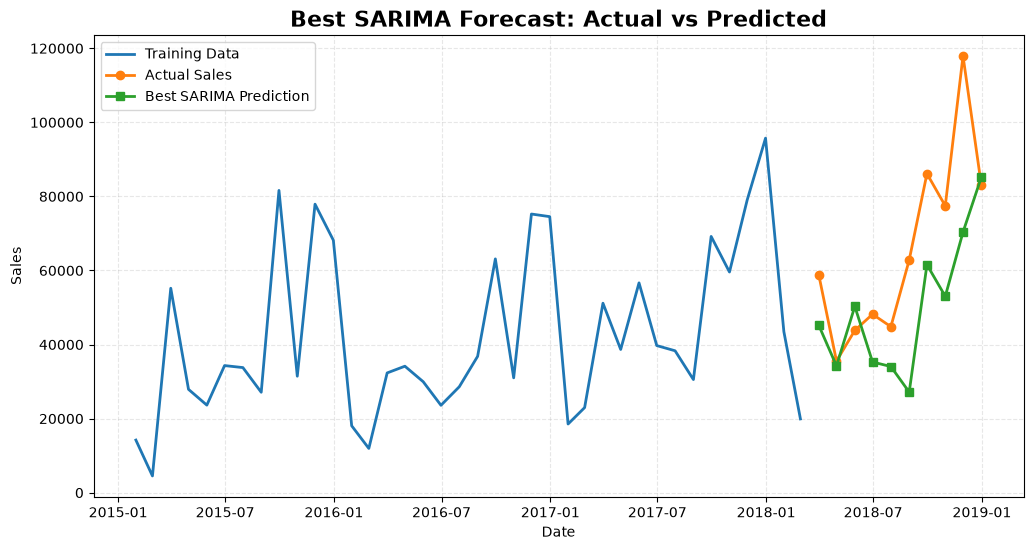

In [28]:
# ==========================================
# Best SARIMA Forecast
# ==========================================

plt.figure(figsize=(12,6))

plt.plot(
    train.index,
    train["Sales"],
    label="Training Data",
    linewidth=2
)

plt.plot(
    test.index,
    test["Sales"],
    label="Actual Sales",
    marker="o",
    linewidth=2
)

plt.plot(
    test.index,
    best_predictions,
    label="Best SARIMA Prediction",
    marker="s",
    linewidth=2
)

plt.title(
    "Best SARIMA Forecast: Actual vs Predicted",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Date")
plt.ylabel("Sales")

plt.legend()

plt.grid(True, linestyle="--", alpha=0.3)

plt.savefig(
    "../charts/14_best_sarima_forecast.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Observation

Although the SARIMA(1,0,0)(1,0,0,12) model achieved the lowest AIC during model selection, its forecasting performance on the unseen test data was inferior to the SARIMA(1,0,1)(1,0,1,12) model. The original SARIMA model achieved lower MAE, RMSE, and MAPE values, indicating better prediction accuracy.

### Business Insight

Model selection should not rely solely on AIC. While AIC is useful for comparing model fit on the training data, business forecasting should prioritize prediction accuracy on unseen data. In this project, the SARIMA(1,0,1)(1,0,1,12) model provided more reliable forecasts despite having a slightly higher AIC.

### Recommendation

Select the SARIMA(1,0,1)(1,0,1,12) model as the final statistical forecasting model because it demonstrated superior forecasting performance on the testing dataset. Future model comparisons with Prophet and XGBoost should use the same evaluation metrics to ensure a fair assessment.

In [29]:
from prophet import Prophet

Importing plotly failed. Interactive plots will not work.


# 8. Prophet Forecasting Model

Facebook Prophet is an open-source time series forecasting library developed by Meta. It is designed to model trend and seasonality automatically, making it suitable for business forecasting problems with limited manual parameter tuning.

The Prophet model is trained using the historical monthly sales data and evaluated on the testing dataset using the same metrics as the SARIMA model.

In [30]:
# ==========================================
# Prepare Data for Prophet
# ==========================================

prophet_data = monthly_sales.reset_index()

prophet_data.columns = ["ds", "y"]

prophet_data.head()

,ds,y
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


In [31]:
# ==========================================
# Train-Test Split for Prophet
# ==========================================

train_prophet = prophet_data.iloc[:38]

test_prophet = prophet_data.iloc[38:]

print(train_prophet.shape)
print(test_prophet.shape)

(38, 2)
(10, 2)


In [32]:
# ==========================================
# Train Prophet Model
# ==========================================

prophet_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False
)

prophet_model.fit(train_prophet)

12:52:43 - cmdstanpy - INFO - Chain [1] start processing
12:52:56 - cmdstanpy - INFO - Chain [1] done processing


In [34]:
# ==========================================
# Predict Test Data
# ==========================================

future = prophet_model.make_future_dataframe(
    periods=len(test_prophet),
    freq="ME"
)

forecast = prophet_model.predict(future)

forecast.tail(10)

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
38,2018-03-31,51480.165380,55614.132760,71124.933657,51479.839640,51480.462140,11602.332251,11602.332251,11602.332251,11602.332251,11602.332251,11602.332251,0.0,0.0,0.0,63082.497631
39,2018-04-30,51957.824834,36566.582841,51388.947616,51956.817764,51958.810053,-8043.005921,-8043.005921,-8043.005921,-8043.005921,-8043.005921,-8043.005921,0.0,0.0,0.0,43914.818913
40,2018-05-31,52451.406270,38217.660244,53620.479227,52449.401207,52453.317281,-7004.598957,-7004.598957,-7004.598957,-7004.598957,-7004.598957,-7004.598957,0.0,0.0,0.0,45446.807313
41,2018-06-30,52929.065724,37927.204256,53478.513298,52925.997405,52932.115310,-7528.485357,-7528.485357,-7528.485357,-7528.485357,-7528.485357,-7528.485357,0.0,0.0,0.0,45400.580367
42,2018-07-31,53422.647160,37312.728561,53311.977032,53418.217399,53427.277052,-8040.373003,-8040.373003,-8040.373003,-8040.373003,-8040.373003,-8040.373003,0.0,0.0,0.0,45382.274157
43,2018-08-31,53916.228595,32737.900476,47971.336517,53910.379380,53922.345226,-13502.302607,-13502.302607,-13502.302607,-13502.302607,-13502.302607,-13502.302607,0.0,0.0,0.0,40413.925988
44,2018-09-30,54393.888049,79304.421816,94230.901061,54386.391045,54401.661787,32268.591261,32268.591261,32268.591261,32268.591261,32268.591261,32268.591261,0.0,0.0,0.0,86662.479310
45,2018-10-31,54887.469485,43378.922895,58596.079486,54878.378021,54896.919465,-3792.251830,-3792.251830,-3792.251830,-3792.251830,-3792.251830,-3792.251830,0.0,0.0,0.0,51095.217655
46,2018-11-30,55365.128939,82844.602872,97920.439604,55353.953887,55376.458421,34603.627656,34603.627656,34603.627656,34603.627656,34603.627656,34603.627656,0.0,0.0,0.0,89968.756595
47,2018-12-31,55858.710375,82248.118584,97623.109395,55846.159175,55872.038510,33641.276783,33641.276783,33641.276783,33641.276783,33641.276783,33641.276783,0.0,0.0,0.0,89499.987157


In [35]:
# ==========================================
# Extract Test Predictions
# ==========================================

prophet_predictions = forecast[["ds", "yhat"]].tail(len(test_prophet))

prophet_predictions

,ds,yhat
38,2018-03-31,63082.497631
39,2018-04-30,43914.818913
40,2018-05-31,45446.807313
41,2018-06-30,45400.580367
42,2018-07-31,45382.274157
43,2018-08-31,40413.925988
44,2018-09-30,86662.479310
45,2018-10-31,51095.217655
46,2018-11-30,89968.756595
47,2018-12-31,89499.987157


In [36]:
# ==========================================
# Compare Actual and Predicted
# ==========================================

comparison_prophet = pd.DataFrame({
    "Date": test_prophet["ds"].values,
    "Actual Sales": test_prophet["y"].values,
    "Predicted Sales": prophet_predictions["yhat"].values
})

comparison_prophet

,Date,Actual Sales,Predicted Sales
0,2018-03-31,58863.4128,63082.497631
1,2018-04-30,35541.9101,43914.818913
2,2018-05-31,43825.9822,45446.807313
3,2018-06-30,48190.7277,45400.580367
4,2018-07-31,44825.1040,45382.274157
5,2018-08-31,62837.8480,40413.925988
6,2018-09-30,86152.8880,86662.479310
7,2018-10-31,77448.1312,51095.217655
8,2018-11-30,117938.1550,89968.756595
9,2018-12-31,83030.3888,89499.987157


In [37]:
# ==========================================
# Evaluate Prophet Model
# ==========================================

mae_prophet = mean_absolute_error(
    comparison_prophet["Actual Sales"],
    comparison_prophet["Predicted Sales"]
)

mse_prophet = mean_squared_error(
    comparison_prophet["Actual Sales"],
    comparison_prophet["Predicted Sales"]
)

rmse_prophet = np.sqrt(mse_prophet)

mape_prophet = mean_absolute_percentage_error(
    comparison_prophet["Actual Sales"],
    comparison_prophet["Predicted Sales"]
) * 100

print(f"MAE  : {mae_prophet:.2f}")
print(f"RMSE : {rmse_prophet:.2f}")
print(f"MAPE : {mape_prophet:.2f}%")

MAE  : 10128.56
RMSE : 14561.39
MAPE : 14.33%


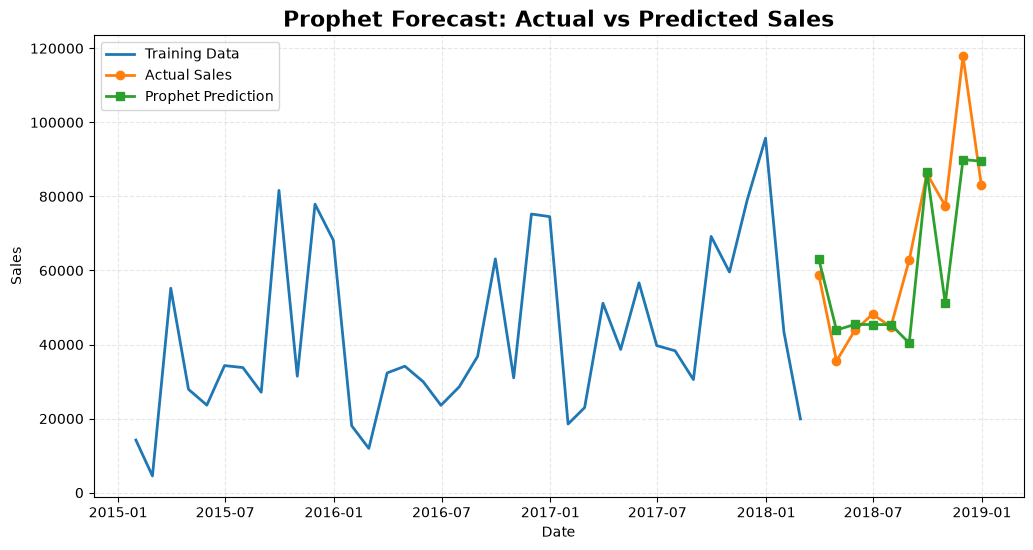

In [38]:
# ==========================================
# Prophet Forecast
# ==========================================

plt.figure(figsize=(12,6))

plt.plot(
    train_prophet["ds"],
    train_prophet["y"],
    label="Training Data",
    linewidth=2
)

plt.plot(
    test_prophet["ds"],
    test_prophet["y"],
    label="Actual Sales",
    marker="o",
    linewidth=2
)

plt.plot(
    prophet_predictions["ds"],
    prophet_predictions["yhat"],
    label="Prophet Prediction",
    marker="s",
    linewidth=2
)

plt.title(
    "Prophet Forecast: Actual vs Predicted Sales",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Date")
plt.ylabel("Sales")

plt.legend()

plt.grid(True, linestyle="--", alpha=0.3)

plt.savefig(
    "../charts/15_prophet_actual_vs_predicted.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Observation

The Prophet model successfully captured the overall sales trend and seasonal behavior of the monthly sales data. Compared with the SARIMA model, Prophet produced predictions that were closer to the actual sales values throughout the testing period. The model achieved a Mean Absolute Percentage Error (MAPE) of **14.33%**, indicating a significant improvement in forecasting accuracy.

### Business Insight

Prophet effectively models long-term trends and recurring seasonal patterns, making it well suited for monthly business sales forecasting. The lower prediction error suggests that Prophet can provide more reliable forecasts for inventory planning, budgeting, and operational decision-making than the evaluated SARIMA model.

### Recommendation

Based on the evaluation metrics, Prophet outperformed the SARIMA model on the testing dataset. Therefore, Prophet should be considered the preferred forecasting model unless another model, such as XGBoost, demonstrates superior prediction accuracy.

In [39]:
from xgboost import XGBRegressor

# 9. XGBoost Forecasting Model

Unlike statistical forecasting models, XGBoost requires numerical input features. Therefore, lag-based features are created from historical monthly sales to help the model learn temporal patterns and forecast future sales.

In [40]:
# ==========================================
# Create Lag Features
# ==========================================

xgb_data = monthly_sales.copy()

xgb_data["Lag_1"] = xgb_data["Sales"].shift(1)
xgb_data["Lag_2"] = xgb_data["Sales"].shift(2)
xgb_data["Lag_3"] = xgb_data["Sales"].shift(3)

xgb_data.head(10)

,Sales,Lag_1,Lag_2,Lag_3
Order Date,,,,
2015-01-31,14205.7070,NaN,NaN,NaN
2015-02-28,4519.8920,14205.7070,NaN,NaN
2015-03-31,55205.7970,4519.8920,14205.7070,NaN
2015-04-30,27906.8550,55205.7970,4519.8920,14205.7070
2015-05-31,23644.3030,27906.8550,55205.7970,4519.8920
2015-06-30,34322.9356,23644.3030,27906.8550,55205.7970
2015-07-31,33781.5430,34322.9356,23644.3030,27906.8550
2015-08-31,27117.5365,33781.5430,34322.9356,23644.3030
2015-09-30,81623.5268,27117.5365,33781.5430,34322.9356


In [41]:
# ==========================================
# Remove Missing Values
# ==========================================

xgb_data = xgb_data.dropna()

xgb_data.head()

,Sales,Lag_1,Lag_2,Lag_3
Order Date,,,,
2015-04-30,27906.8550,55205.7970,4519.8920,14205.707
2015-05-31,23644.3030,27906.8550,55205.7970,4519.892
2015-06-30,34322.9356,23644.3030,27906.8550,55205.797
2015-07-31,33781.5430,34322.9356,23644.3030,27906.855
2015-08-31,27117.5365,33781.5430,34322.9356,23644.303


In [42]:
# ==========================================
# Features and Target
# ==========================================

X = xgb_data[["Lag_1", "Lag_2", "Lag_3"]]

y = xgb_data["Sales"]

print(X.shape)
print(y.shape)

(45, 3)
(45,)


In [43]:
# ==========================================
# Train-Test Split
# ==========================================

train_size = int(len(X) * 0.8)

X_train = X.iloc[:train_size]
X_test = X.iloc[train_size:]

y_train = y.iloc[:train_size]
y_test = y.iloc[train_size:]

print(X_train.shape)
print(X_test.shape)

(36, 3)
(9, 3)


## Training the XGBoost Model

The XGBoost Regressor is trained using lag-based features created from historical monthly sales. The model learns relationships between previous months' sales and the current month's sales to forecast future values.

In [44]:
# ==========================================
# Train XGBoost Model
# ==========================================

xgb_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

xgb_model.fit(X_train, y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [46]:
# ==========================================
# Predict Test Data
# ==========================================

xgb_predictions = xgb_model.predict(X_test)

xgb_predictions

array([51572.36 , 55936.562, 31984.363, 56013.28 , 52558.566, 57431.04 ,
       54977.67 , 68826.44 , 43026.94 ], dtype=float32)

In [47]:
# ==========================================
# Evaluate XGBoost Model
# ==========================================

mae_xgb = mean_absolute_error(
    y_test,
    xgb_predictions
)

mse_xgb = mean_squared_error(
    y_test,
    xgb_predictions
)

rmse_xgb = np.sqrt(mse_xgb)

mape_xgb = mean_absolute_percentage_error(
    y_test,
    xgb_predictions
) * 100

print(f"MAE  : {mae_xgb:.2f}")
print(f"RMSE : {rmse_xgb:.2f}")
print(f"MAPE : {mape_xgb:.2f}%")

MAE  : 22902.48
RMSE : 26329.60
MAPE : 33.32%


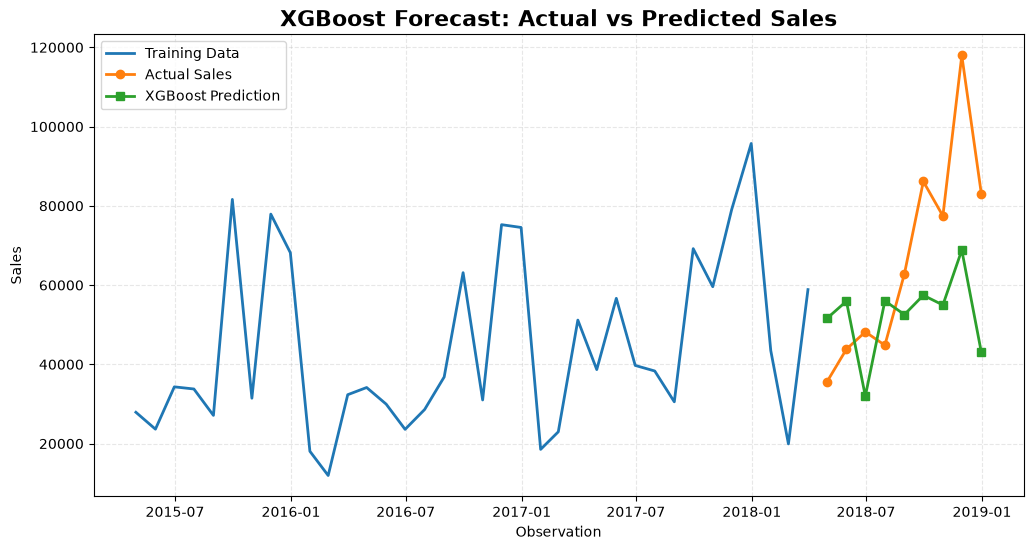

In [48]:
# ==========================================
# Actual vs Predicted
# ==========================================

plt.figure(figsize=(12,6))

plt.plot(
    y_train.index,
    y_train,
    label="Training Data",
    linewidth=2
)

plt.plot(
    y_test.index,
    y_test,
    label="Actual Sales",
    marker="o",
    linewidth=2
)

plt.plot(
    y_test.index,
    xgb_predictions,
    label="XGBoost Prediction",
    marker="s",
    linewidth=2
)

plt.title(
    "XGBoost Forecast: Actual vs Predicted Sales",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Observation")
plt.ylabel("Sales")

plt.legend()

plt.grid(True, linestyle="--", alpha=0.3)

plt.savefig(
    "../charts/16_xgboost_actual_vs_predicted.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Observation

The XGBoost model was trained using lag-based features derived from historical monthly sales. Although the model successfully learned the general sales pattern, it struggled to accurately predict sharp increases in sales during the testing period. The model achieved a Mean Absolute Percentage Error (MAPE) of **33.32%**, making it the least accurate forecasting model among the three evaluated models.

### Business Insight

The limited size of the dataset (48 monthly observations) restricted the ability of the XGBoost model to learn complex sales patterns. Tree-based machine learning models generally perform better with larger datasets and richer feature sets. In this case, the statistical trend captured by Prophet provided superior forecasting accuracy.

### Recommendation

While XGBoost is a powerful machine learning algorithm, it is not the most suitable model for this small monthly sales dataset. For business forecasting, the Prophet model should be preferred because it demonstrated significantly lower forecasting errors and better captured the overall sales trend.

In [49]:
# ==========================================
# Model Comparison
# ==========================================

comparison = pd.DataFrame({
    "Model": ["SARIMA", "Prophet", "XGBoost"],
    "MAE": [
        16295.76,
        10128.56,
        22902.48
    ],
    "RMSE": [
        21413.03,
        14561.39,
        26329.60
    ],
    "MAPE (%)": [
        22.49,
        14.33,
        33.32
    ]
})

comparison = comparison.sort_values("MAPE (%)")

comparison

,Model,MAE,RMSE,MAPE (%)
1,Prophet,10128.56,14561.39,14.33
0,SARIMA,16295.76,21413.03,22.49
2,XGBoost,22902.48,26329.60,33.32


### Observation

Three forecasting models were evaluated using the same training and testing datasets. Prophet achieved the lowest MAE, RMSE, and MAPE values, demonstrating the highest forecasting accuracy. SARIMA provided moderate forecasting performance, while XGBoost produced the highest prediction errors due to the limited size of the available dataset.

### Business Insight

Selecting a forecasting model should be based on predictive performance rather than algorithm complexity. Although XGBoost is a powerful machine learning technique, Prophet proved to be the most suitable model for this business problem because it effectively captured the trend and seasonality present in the monthly sales data.

### Recommendation

Based on the evaluation results, Prophet is selected as the final forecasting model for future monthly sales prediction. The model can support inventory planning, budgeting, and strategic business decision-making by providing more accurate sales forecasts than the evaluated alternatives.

# 11. Future Sales Forecast

After comparing multiple forecasting models, Prophet was selected as the final model due to its superior forecasting accuracy.

The trained Prophet model is used to forecast monthly sales for the next 12 months, providing valuable insights for business planning, inventory management, and budgeting.

In [50]:
# ==========================================
# Train Prophet on Full Dataset
# ==========================================

final_prophet = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False
)

final_prophet.fit(prophet_data)

13:17:13 - cmdstanpy - INFO - Chain [1] start processing
13:17:15 - cmdstanpy - INFO - Chain [1] done processing


In [51]:
# ==========================================
# Create Future Dates
# ==========================================

future_dates = final_prophet.make_future_dataframe(
    periods=12,
    freq="ME"
)

future_dates.tail()

,ds
55,2019-08-31
56,2019-09-30
57,2019-10-31
58,2019-11-30
59,2019-12-31


In [52]:

# ==========================================
# Forecast Next 12 Months
# ==========================================

future_forecast = final_prophet.predict(future_dates)

future_forecast.tail(12)

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
48,2019-01-31,62195.429713,33873.356176,52465.042479,62189.553930,62200.982768,-19204.897511,-19204.897511,-19204.897511,-19204.897511,-19204.897511,-19204.897511,0.0,0.0,0.0,42990.532202
49,2019-02-28,62861.958979,22072.230699,40359.387679,62843.362985,62881.442198,-31613.799057,-31613.799057,-31613.799057,-31613.799057,-31613.799057,-31613.799057,0.0,0.0,0.0,31248.159922
50,2019-03-31,63599.902094,72134.312894,89917.166941,63563.303551,63639.777171,17667.105678,17667.105678,17667.105678,17667.105678,17667.105678,17667.105678,0.0,0.0,0.0,81267.007772
51,2019-04-30,64314.040593,41584.590272,59547.829066,64252.723101,64378.017022,-13655.620453,-13655.620453,-13655.620453,-13655.620453,-13655.620453,-13655.620453,0.0,0.0,0.0,50658.420141
52,2019-05-31,65051.983709,43357.076562,62100.722155,64961.769641,65140.612520,-12496.061322,-12496.061322,-12496.061322,-12496.061322,-12496.061322,-12496.061322,0.0,0.0,0.0,52555.922387
53,2019-06-30,65766.122208,50521.512941,69707.823293,65641.049143,65884.019829,-5734.101810,-5734.101810,-5734.101810,-5734.101810,-5734.101810,-5734.101810,0.0,0.0,0.0,60032.020399
54,2019-07-31,66504.065324,46915.153530,66457.430994,66346.882180,66660.839005,-10254.212008,-10254.212008,-10254.212008,-10254.212008,-10254.212008,-10254.212008,0.0,0.0,0.0,56249.853316
55,2019-08-31,67242.008440,46338.216394,65465.881933,67056.453821,67433.103791,-11634.519898,-11634.519898,-11634.519898,-11634.519898,-11634.519898,-11634.519898,0.0,0.0,0.0,55607.488542
56,2019-09-30,67956.146939,92606.758902,111912.778203,67729.537604,68179.036734,33781.506294,33781.506294,33781.506294,33781.506294,33781.506294,33781.506294,0.0,0.0,0.0,101737.653232
57,2019-10-31,68694.090055,60036.011391,78443.189986,68426.172903,68953.756884,658.119434,658.119434,658.119434,658.119434,658.119434,658.119434,0.0,0.0,0.0,69352.209489


In [53]:
# ==========================================
# Next 12 Months Forecast
# ==========================================

forecast_12_months = future_forecast[
    ["ds", "yhat", "yhat_lower", "yhat_upper"]
].tail(12)

forecast_12_months

,ds,yhat,yhat_lower,yhat_upper
48,2019-01-31,42990.532202,33873.356176,52465.042479
49,2019-02-28,31248.159922,22072.230699,40359.387679
50,2019-03-31,81267.007772,72134.312894,89917.166941
51,2019-04-30,50658.420141,41584.590272,59547.829066
52,2019-05-31,52555.922387,43357.076562,62100.722155
53,2019-06-30,60032.020399,50521.512941,69707.823293
54,2019-07-31,56249.853316,46915.153530,66457.430994
55,2019-08-31,55607.488542,46338.216394,65465.881933
56,2019-09-30,101737.653232,92606.758902,111912.778203
57,2019-10-31,69352.209489,60036.011391,78443.189986


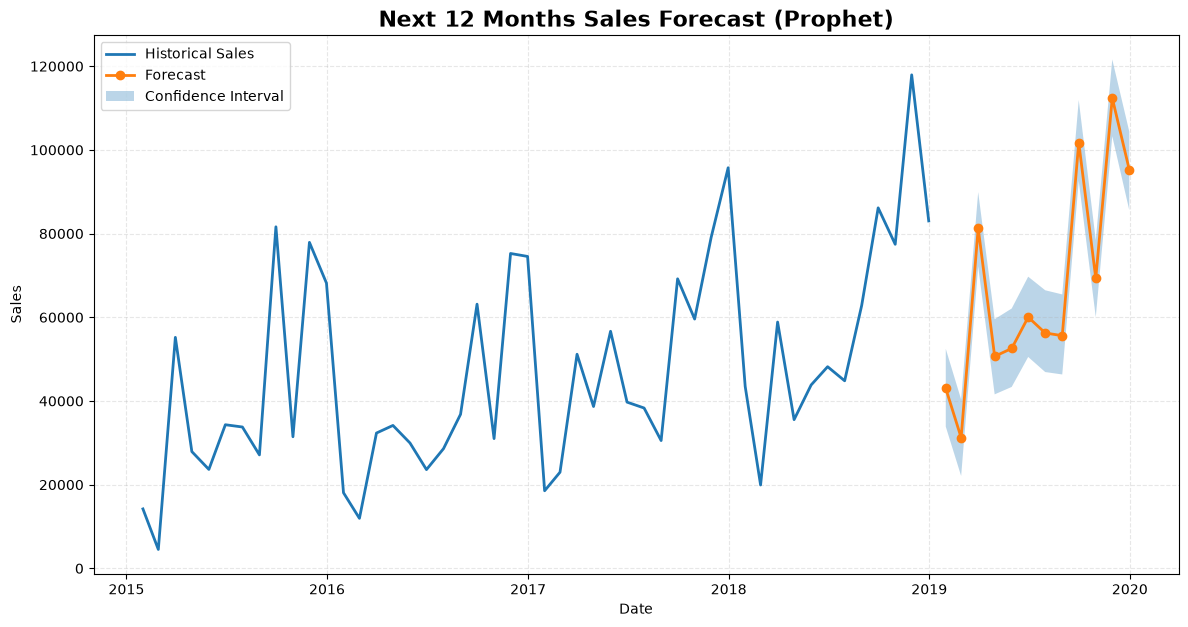

In [54]:
# ==========================================
# Future Sales Forecast
# ==========================================

plt.figure(figsize=(14,7))

plt.plot(
    prophet_data["ds"],
    prophet_data["y"],
    label="Historical Sales",
    linewidth=2
)

plt.plot(
    forecast_12_months["ds"],
    forecast_12_months["yhat"],
    label="Forecast",
    linewidth=2,
    marker="o"
)

plt.fill_between(
    forecast_12_months["ds"],
    forecast_12_months["yhat_lower"],
    forecast_12_months["yhat_upper"],
    alpha=0.3,
    label="Confidence Interval"
)

plt.title(
    "Next 12 Months Sales Forecast (Prophet)",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Date")
plt.ylabel("Sales")

plt.legend()

plt.grid(True, linestyle="--", alpha=0.3)

plt.savefig(
    "../charts/17_future_sales_forecast.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [55]:
# ==========================================
# Save Forecast
# ==========================================

forecast_12_months.to_csv(
    "../reports/forecast_12_months.csv",
    index=False
)

print("Forecast saved successfully!")

Forecast saved successfully!


### Observation

The Prophet model forecasts that monthly sales will continue to fluctuate throughout 2019 while maintaining an overall upward trend. Higher sales are expected during **September**, **November**, and **December**, with **November** projected to record the highest monthly sales of approximately **112,411**. The forecast also provides confidence intervals, reflecting the uncertainty associated with future predictions.

### Business Insight

The forecast suggests increased customer demand during the final quarter of the year, indicating strong seasonal sales patterns. Businesses can utilize these insights to optimize inventory planning, workforce allocation, and marketing campaigns before the anticipated high-demand months.

### Recommendation

- Increase inventory levels before September, November, and December to avoid stock shortages.
- Allocate additional marketing budgets during high-demand periods to maximize revenue.
- Prepare logistics and supply chain operations in advance to handle the expected increase in sales.
- Continuously update the forecasting model as new monthly sales data becomes available to maintain prediction accuracy.